In [1]:
using SpeedyWeather, GLMakie

In [2]:
spectral_grid = SpectralGrid()

SpectralGrid{Spectrum{...}, OctahedralGaussianGrid{...}}
├ Number format: Float32
├ Spectral:      T31 LowerTriangularMatrix
├ Grid:          48-ring OctahedralGaussianGrid, 3168 grid points
├ Resolution:    3.61°, 401km (at 6371km radius)
├ Vertical:      8-layer atmosphere, 2-layer land
└ Architecture:  CPU using Array

In [4]:
model = PrimitiveWetModel(spectral_grid)
simulation = initialize!(model)

Simulation{PrimitiveWetModel}
├ prognostic_variables::PrognosticVariables{...}
├ diagnostic_variables::DiagnosticVariables{...}
└ model::PrimitiveWetModel{...}

## Output variables

In [5]:
model.output

NetCDFOutput{Field{Float32, 1, Vector{Float32}, FullGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ status: inactive/uninitialized
├ write restart file: true (if active)
├ interpolator: AnvilInterpolator{Float32, RingGrids.GridGeometry{OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Vector{Float32}, Vector{Int64}, Vector{UnitRange{Int64}}}, RingGrids.AnvilLocator{Float32, Vector{Float32}, Vector{Int64}}}
├ path: output.nc (overwrite=false)
├ frequency: 21600 seconds
└┐ variables:
 ├ v: meridional wind [m/s]
 ├ humid: specific humidity [kg/kg]
 ├ temp: temperature [degC]
 ├ u: zonal wind [m/s]
 ├ mslp: mean sea-level pressure [hPa]
 └ vor: relative vorticity [s^-1]

In [6]:
add!(model, SpeedyWeather.RadiationOutput()...)

NetCDFOutput{Field{Float32, 1, Vector{Float32}, FullGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ status: inactive/uninitialized
├ write restart file: true (if active)
├ interpolator: AnvilInterpolator{Float32, RingGrids.GridGeometry{OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Vector{Float32}, Vector{Int64}, Vector{UnitRange{Int64}}}, RingGrids.AnvilLocator{Float32, Vector{Float32}, Vector{Int64}}}
├ path: output.nc (overwrite=false)
├ frequency: 21600 seconds
└┐ variables:
 ├ sru: Surface shortwave radiation up [W/m^2]
 ├ temp: temperature [degC]
 ├ srd: Surface shortwave radiation down [W/m^2]
 ├ mslp: mean sea-level pressure [hPa]
 ├ vor: relative vorticity [s^-1]
 ├ osr: Outgoing shortwave radiation [W/m^2]
 ├ v: meridional wind [m/s]
 ├ u: zonal wind [m/s]
 ├ albedo: albedo [1]
 ├ lrd: Surface longwave radiation down [W/m^2]
 ├ humid: specific humidity [kg/kg]
 ├ olr: Outgoing longwave radia

In [8]:
add!(model, SpeedyWeather.SurfaceFluxesOutput()...)

NetCDFOutput{Field{Float32, 1, Vector{Float32}, FullGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ status: inactive/uninitialized
├ write restart file: true (if active)
├ interpolator: AnvilInterpolator{Float32, RingGrids.GridGeometry{OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Vector{Float32}, Vector{Int64}, Vector{UnitRange{Int64}}}, RingGrids.AnvilLocator{Float32, Vector{Float32}, Vector{Int64}}}
├ path: output.nc (overwrite=false)
├ frequency: 21600 seconds
└┐ variables:
 ├ slf: Surface latent heat flux (positive up) [W/m^2]
 ├ sru: Surface shortwave radiation up [W/m^2]
 ├ temp: temperature [degC]
 ├ srd: Surface shortwave radiation down [W/m^2]
 ├ mslp: mean sea-level pressure [hPa]
 ├ vor: relative vorticity [s^-1]
 ├ osr: Outgoing shortwave radiation [W/m^2]
 ├ v: meridional wind [m/s]
 ├ u: zonal wind [m/s]
 ├ albedo: albedo [1]
 ├ lrd: Surface longwave radiation down [W/m^2]
 ├ shf: Surf

In [11]:
simulation.diagnostic_variables.physics.sensible_heat_flux

3168-element, 48-ring OctahedralGaussianField{Float32, 1} as Array on CPU
  36.712433f0
  33.193367f0
  36.22802f0
  53.737274f0
  88.132126f0
 131.75328f0
 172.5648f0
 201.82182f0
 219.54616f0
 231.514f0
 241.1357f0
 244.82076f0
 235.31743f0
   ⋮
   0.0f0
   0.0f0
   0.0f0
   0.0f0
   0.0f0
   0.0f0
   0.0f0
   0.0f0
   0.0f0
   0.0f0
   0.0f0
   0.0f0

In [18]:
run!(simulation, period=Day(30))

Weather is speedy: 100%|██████████████████| Time: 0:00:08 (839.42 years/day)


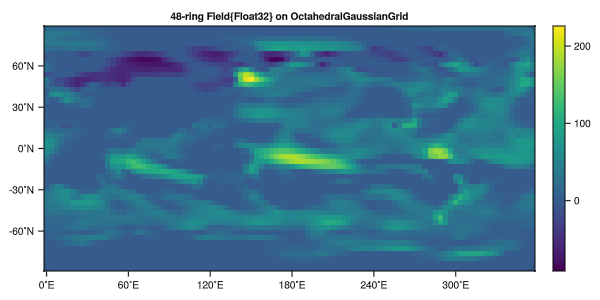

In [14]:
heatmap(simulation.diagnostic_variables.physics.sensible_heat_flux)

In [15]:
simulation.prognostic_variables.clock

Clock
├ time::DateTime = 2000-02-10T00:00:00
├ start::DateTime = 2000-01-11T00:00:00
├ period::Second = 2592000 seconds
├ timestep_counter::Int64 = 1080
├ n_timesteps::Int64 = 1080
└ Δt::Millisecond = 2400000 milliseconds

In [17]:
trenberth(simulation)

LoadError: UndefVarError: `trenberth` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [19]:
real(transform(field)[1]) / model.spectral_transform.norm_sphere

LoadError: UndefVarError: `field` not defined in `Main`
Suggestion: check for spelling errors or missing imports.